In [1]:
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("13-email_classification_svm.csv")

In [3]:
df.head()

,subject_formality_score,sender_relationship_score,email_type
0,-1.496790,0.779258,0
1,-1.217610,0.889601,0
2,-0.375945,-0.823324,1
3,0.639609,-0.362827,1
4,-1.342836,-1.040502,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   subject_formality_score    1000 non-null   float64
 1   sender_relationship_score  1000 non-null   float64
 2   email_type                 1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB


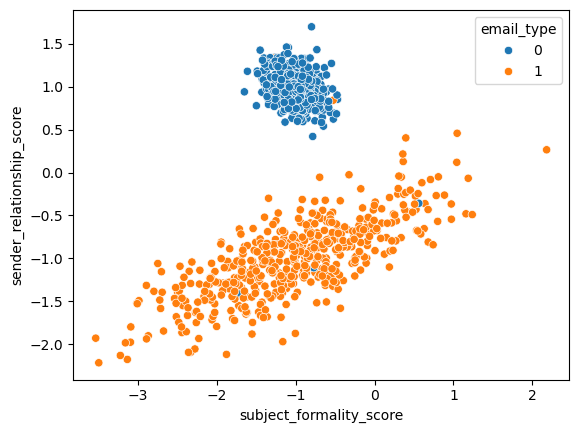

In [5]:
sns.scatterplot(x = df['subject_formality_score'], y = df['sender_relationship_score'], hue = df['email_type'])
plt.show()

In [6]:
X = df.drop('email_type', axis = 1).values
y = df['email_type'].values

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

In [9]:
X_train = torch.tensor(X_train, dtype = torch.float32)
X_test = torch.tensor(X_test, dtype = torch.float32)

y_train = torch.tensor(y_train, dtype = torch.float32)
y_test = torch.tensor(y_test, dtype = torch.float32)

In [10]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([800, 2]) torch.Size([800])
torch.Size([200, 2]) torch.Size([200])


Burada dimensionlar eşleşmediği için shape problemi çıkacak. Bundan dolayı y değerlerine unsqueeze yapacağız.

In [11]:
y_train = y_train.unsqueeze(1)
y_test = y_test.unsqueeze(1)

In [12]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([800, 2]) torch.Size([800, 1])
torch.Size([200, 2]) torch.Size([200, 1])


In [13]:
from torch import nn

In [14]:
class ClassifactionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(in_features=2, out_features=5)
        self.layer2 = nn.Linear(in_features=5, out_features=1)

    def forward(self, x : torch.Tensor):
        return self.layer2(self.layer1(x))

In [15]:
model_0 = ClassifactionModel()

In [16]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(
    params=model_0.parameters(),
    lr = 0.01
)

Accuracy değerini hesaplamak için bir fonksiyon yazacağız. Öncelikle `torch.eq()`'in ne işe yaradığını görelim.

In [17]:
torch.eq(torch.tensor([1,0,0,0,1]), torch.tensor([1,1,1,1,1]))

tensor([ True, False, False, False,  True])

In [18]:
torch.eq(torch.tensor([1,0,0,0,1]), torch.tensor([1,1,1,1,1])).sum().item()

2

İki tensörü karşılaştırıp eşit olanların sayısını bize veriyor.

In [19]:
def calculate_accuracy(y_test, y_pred):
    correct = torch.eq(y_test, y_pred).sum().item()
    accuracy = (correct / len(y_pred)) * 100
    return accuracy

Şimdi de sigmoidin kullanım mantığını inceleyelim

In [20]:
y_logits = model_0(X_test[:5])
y_logits

tensor([[0.3050],
        [0.3807],
        [0.3077],
        [0.3877],
        [0.3054]], grad_fn=<AddmmBackward0>)

In [21]:
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.5757],
        [0.5940],
        [0.5763],
        [0.5957],
        [0.5758]], grad_fn=<SigmoidBackward0>)

In [22]:
y_preds = torch.round(y_pred_probs)
y_preds

tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.]], grad_fn=<RoundBackward0>)

Öncelikle logits değerini hesaplıyor modelimiz. Daha sonra bunu bir sigmoid fonksiyonuna verip olasılık hesaplıyoruz. Ardından round() fonksiyonu ile 1'e veya 0'a yuvarlıyoruz.

In [23]:
torch.manual_seed(42)
epochs = 100

for epoch in range(epochs):
    model_0.train()

    # 1. Forward Pass
    y_logits = model_0(X_train)
    y_pred = torch.round(torch.sigmoid(y_logits))

    # 2. Calculate Loss / Accuracy
    loss = loss_fn(y_logits, y_train)   # BCEWithLogitsLoss kullandığım için böyle yazdım
    acc = calculate_accuracy(y_train, y_pred)

    # 3. Optimizer Zero Grad
    optimizer.zero_grad()

    # 4. Loss Backward
    loss.backward()

    # 5. Optimizer Step
    optimizer.step()

    model_0.eval()
    with torch.inference_mode():
        test_logits = model_0(X_test)
        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits, y_test)
        test_acc = calculate_accuracy(y_test, test_pred)

    if epoch % 5 == 0:
        print(f"Epoch: {epoch} | Train Loss: {loss:.5f} | Train Acc: {acc:.2f} | Test Loss: {test_loss:.5f} | Test Acc: {test_acc:.2f}")

Epoch: 0 | Train Loss: 0.68364 | Train Acc: 50.25 | Test Loss: 0.68931 | Test Acc: 48.00
Epoch: 5 | Train Loss: 0.67610 | Train Acc: 50.25 | Test Loss: 0.68140 | Test Acc: 48.00
Epoch: 10 | Train Loss: 0.66873 | Train Acc: 50.25 | Test Loss: 0.67364 | Test Acc: 48.00
Epoch: 15 | Train Loss: 0.66147 | Train Acc: 50.25 | Test Loss: 0.66602 | Test Acc: 48.00
Epoch: 20 | Train Loss: 0.65432 | Train Acc: 50.25 | Test Loss: 0.65851 | Test Acc: 48.00
Epoch: 25 | Train Loss: 0.64725 | Train Acc: 50.25 | Test Loss: 0.65108 | Test Acc: 48.00
Epoch: 30 | Train Loss: 0.64025 | Train Acc: 50.25 | Test Loss: 0.64373 | Test Acc: 48.00
Epoch: 35 | Train Loss: 0.63330 | Train Acc: 50.25 | Test Loss: 0.63643 | Test Acc: 48.50
Epoch: 40 | Train Loss: 0.62638 | Train Acc: 52.75 | Test Loss: 0.62917 | Test Acc: 51.00
Epoch: 45 | Train Loss: 0.61947 | Train Acc: 59.62 | Test Loss: 0.62192 | Test Acc: 57.00
Epoch: 50 | Train Loss: 0.61258 | Train Acc: 69.88 | Test Loss: 0.61469 | Test Acc: 71.00
Epoch: 55 | 

In [26]:
import numpy as np
def plot_linear_decision_boundary(model, X, y):

    # layer_1: (5,2)
    # layer_2: (1,5)
    # toplam efektif ağırlık = layer_2.weight @ layer_1.weight = (1,2)
    W1 = model.layer1.weight.detach().numpy()       # shape (5,2)
    b1 = model.layer1.bias.detach().numpy()         # shape (5,)
    W2 = model.layer2.weight.detach().numpy()       # shape (1,5)
    b2 = model.layer2.bias.detach().numpy()[0]      # shape (1,)

    # efektif W ve b
    # W_eff = W2 * W1
    W_eff = W2 @ W1   # shape (1,2)
    w1, w2 = W_eff[0] # iki feature'ın ağırlığı

    # efektif b = W2 * b1 + b2
    b_eff = (W2 @ b1)[0] + b2

    # X aralığı
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    xs = np.linspace(x_min, x_max, 200)

    # Doğru denkleminden x2 hesaplama
    # w1*x1 + w2*x2 + b = 0  →  x2 = -(w1*x1 + b) / w2
    ys = -(w1 * xs + b_eff) / w2

    # Noktalar
    plt.scatter(X[:, 0], X[:, 1], c=y.squeeze(), cmap=plt.cm.RdYlBu, s=40)
    plt.plot(xs, ys, "k-", linewidth=3)
    plt.xlabel("subject_formality_score")
    plt.ylabel("sender_relationship_score")
    plt.xlim(x_min, x_max)
    plt.ylim(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5)

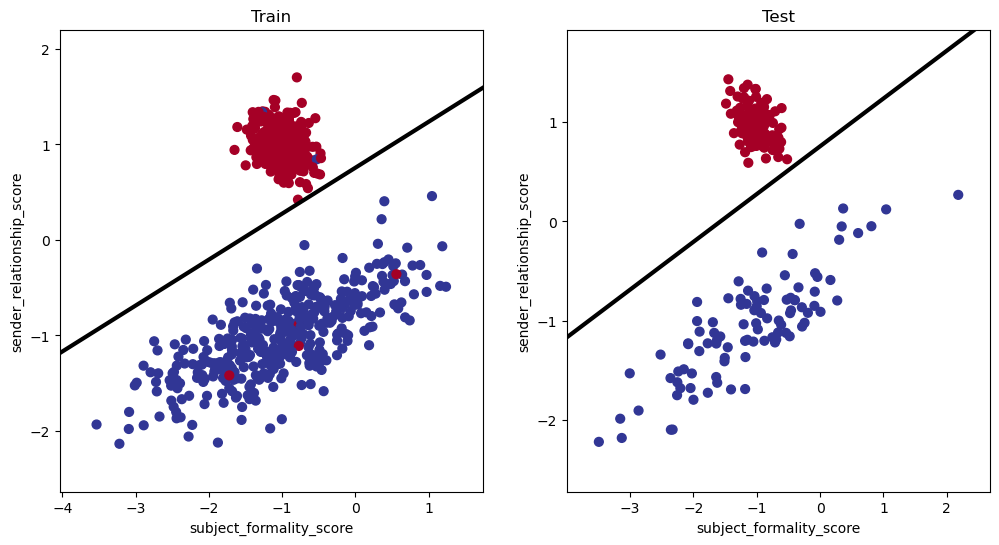

In [27]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Train")
plot_linear_decision_boundary(model_0, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test")
plot_linear_decision_boundary(model_0, X_test, y_test)

plt.show()